In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR

In [33]:
market='Nasdaq'
data=pd.read_parquet(DATA_DIR/'agent'/f'{market}.parquet')
data.head()

,date,hour,minute,price,position,time
0,2020-01-02,0,0,8787.75,0,2020-01-02 06:00:00
1,2020-01-02,0,5,8787.75,0,2020-01-02 06:05:00
2,2020-01-02,0,10,8786.00,0,2020-01-02 06:10:00
3,2020-01-02,0,15,8785.50,0,2020-01-02 06:15:00
4,2020-01-02,0,20,8785.25,0,2020-01-02 06:20:00


In [34]:
data['trade']=data['position'].diff()
data['trade']=data['trade'].fillna(0)
data['position']=data['position'].ffill()
data[['position','trade']].dropna().describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
position,27921.0,4.26,3.64,-11.0,2.0,4.0,7.0,11.0
trade,27921.0,0.00,1.18,-16.0,0.0,0.0,0.0,17.0


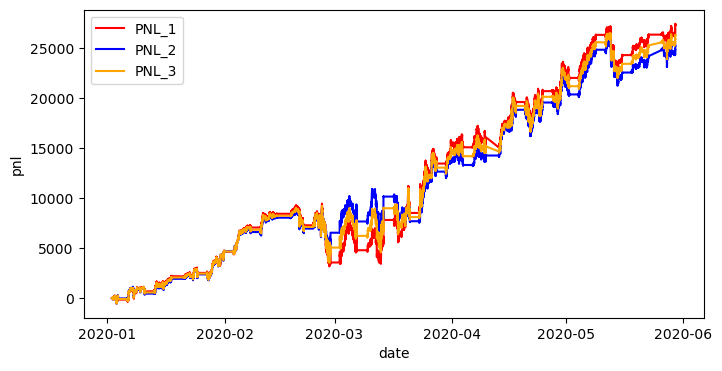

In [35]:
data['cash_1']=-data['trade']*data['price'] # latter price
data['cash_2']=(-data['trade']*data['price'].shift()).fillna(0) # former price
data['cash_3']=(-data['trade']*(data['price'].shift()+data['price'])/2).fillna(0) # middle price
data['inventory']=data['position']*data['price']
data['PNL_1']=data['cash_1'].cumsum()+data['inventory']
data['PNL_2']=data['cash_2'].cumsum()+data['inventory']
data['PNL_3']=data['cash_3'].cumsum()+data['inventory']

plt.figure(figsize=(8,4))
plt.plot(data['time'],data['PNL_1'],color='red',label='PNL_1')
plt.plot(data['time'],data['PNL_2'],color='blue',label='PNL_2')
plt.plot(data['time'],data['PNL_3'],color='orange',label='PNL_3')
plt.xlabel('date')
plt.ylabel('pnl')
plt.legend()
plt.show()

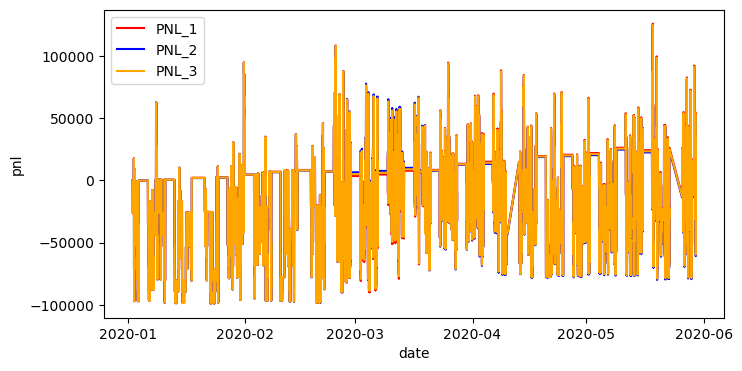

In [37]:
plt.figure(figsize=(8,4))
plt.plot(data['time'],data['cash_1'].cumsum(),color='red',label='PNL_1')
plt.plot(data['time'],data['cash_2'].cumsum(),color='blue',label='PNL_2')
plt.plot(data['time'],data['cash_3'].cumsum(),color='orange',label='PNL_3')
plt.xlabel('date')
plt.ylabel('pnl')
plt.legend()
plt.show()

In [38]:
agent_path=DATA_DIR/'agent'
futures_path=DATA_DIR/'futures'/'minute_5'

market='Nasdaq'
agent_df=pd.read_parquet(agent_path/f'{market}.parquet')
data=pd.read_parquet(futures_path/f'{market}.parquet')

print(f'Number of rows of agent: {len(agent_df)}')
agent_df.head()

Number of rows of agent: 27921


,date,hour,minute,price,position,time
0,2020-01-02,0,0,8787.75,0,2020-01-02 06:00:00
1,2020-01-02,0,5,8787.75,0,2020-01-02 06:05:00
2,2020-01-02,0,10,8786.00,0,2020-01-02 06:10:00
3,2020-01-02,0,15,8785.50,0,2020-01-02 06:15:00
4,2020-01-02,0,20,8785.25,0,2020-01-02 06:20:00


In [39]:
print(f'Number of rows of data: {len(data)}')
data.head()

Number of rows of data: 52473


,time,open,high,low,close,volume,date,contract,n_rows
0,2019-12-13 00:00:00,8508.00,8521.50,8508.00,8518.00,625.0,2019-12-13,0,1.0
1,2019-12-13 00:05:00,8517.50,8524.25,8517.50,8522.75,680.0,2019-12-13,0,1.0
2,2019-12-13 00:10:00,8522.50,8523.25,8521.00,8521.50,163.0,2019-12-13,0,1.0
3,2019-12-13 00:15:00,8521.25,8521.25,8517.50,8518.50,322.0,2019-12-13,0,1.0
4,2019-12-13 00:20:00,8519.00,8521.50,8517.75,8518.25,181.0,2019-12-13,0,1.0


In [40]:
df=agent_df.merge(data[['time','open','high','low','close','volume']],on='time',how='left')

print(f'Number of rows of merged df: {len(df)}')
df.head()

Number of rows of merged df: 27921


,date,hour,minute,price,position,time,open,high,low,close,volume
0,2020-01-02,0,0,8787.75,0,2020-01-02 06:00:00,8787.75,8788.25,8787.25,8787.75,98.0
1,2020-01-02,0,5,8787.75,0,2020-01-02 06:05:00,8787.75,8787.75,8786.00,8786.00,120.0
2,2020-01-02,0,10,8786.00,0,2020-01-02 06:10:00,8786.00,8786.75,8785.50,8785.50,170.0
3,2020-01-02,0,15,8785.50,0,2020-01-02 06:15:00,8785.50,8786.75,8784.50,8785.25,154.0
4,2020-01-02,0,20,8785.25,0,2020-01-02 06:20:00,8785.25,8785.25,8784.50,8784.50,101.0


In [41]:
print(f'Number of times price > high: {(df['price']>df['high']).sum()}')
print(f'Number of times price < low: {(df['price']<df['low']).sum()}')
print(f'Number of times trade > volume: {(df['position'].diff().fillna(0)>df['volume']).sum()}')

Number of times price > high: 746
Number of times price < low: 665
Number of times trade > volume: 1


In [42]:
agent_path=DATA_DIR/'agent'
futures_path=DATA_DIR/'futures'/'minute_5'

files=sorted([p.name for p in agent_path.glob("*.parquet")])
markets=[f[:-8] for f in files]
    
for market in markets:
    print(f'========== {market} ==========')
    agent_df=pd.read_parquet(agent_path/f'{market}.parquet')
    data=pd.read_parquet(futures_path/f'{market}.parquet')

    print(f'Number of rows of agent: {len(agent_df)}')
    print(f'Number of rows of data: {len(data)}')
    df=agent_df.merge(data[['time','open','high','low','close','volume']],on='time',how='left')
    
    high_abnormal=(df['price']>df['high']).sum()
    low_abnormal=(df['price']<df['low']).sum()
    volume_abnormal=(df['position'].diff().fillna(0)>df['volume']).sum()

    print(f'Number of times price > high: {high_abnormal},  pct: {high_abnormal/len(df):.3f}')
    print(f'Number of times price < low: {low_abnormal},  pct: {low_abnormal/len(df):.3f}')
    print(f'Number of times trade > volume: {volume_abnormal},  pct: {volume_abnormal/len(df):.3f}')

========== EuroStoxx ==========
Number of rows of agent: 28004
Number of rows of data: 30743
Number of times price > high: 809,  pct: 0.029
Number of times price < low: 833,  pct: 0.030
Number of times trade > volume: 0,  pct: 0.000
========== GBP - British Pound ==========
Number of rows of agent: 23152
Number of rows of data: 35480
Number of times price > high: 1246,  pct: 0.054
Number of times price < low: 1061,  pct: 0.046
Number of times trade > volume: 0,  pct: 0.000
========== German Bunds - German Government Bonds ==========
Number of rows of agent: 28580
Number of rows of data: 45480
Number of times price > high: 1286,  pct: 0.045
Number of times price < low: 992,  pct: 0.035
Number of times trade > volume: 0,  pct: 0.000
========== Gold ==========
Number of rows of agent: 28497
Number of rows of data: 47090
Number of times price > high: 805,  pct: 0.028
Number of times price < low: 3105,  pct: 0.109
Number of times trade > volume: 0,  pct: 0.000
========== HeatingOil ========

All Markets: ['EuroStoxx', 'GBP - British Pound', 'German Bunds - German Government Bonds', 'Gold', 'HeatingOil', 'JPY - Japanese Yen', 'Nasdaq']
Number of markets: 7
========== EuroStoxx ==========
            count  mean   std  min  25%  50%  75%  max
position  28004.0  2.26  1.81 -3.0  1.0  2.0  4.0  6.0
trade     28004.0  0.00  0.15 -5.0  0.0  0.0  0.0  4.0


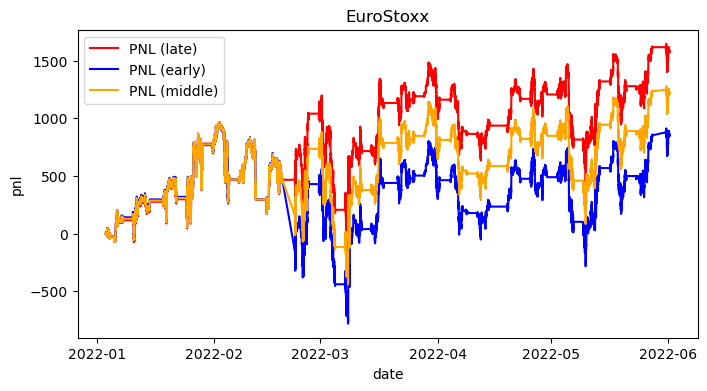

========== GBP - British Pound ==========
            count  mean   std   min  25%  50%  75%   max
position  23152.0 -1.59  5.68 -17.0 -5.0 -1.0  0.0  17.0
trade     23152.0  0.00  0.96 -21.0  0.0  0.0  0.0  29.0


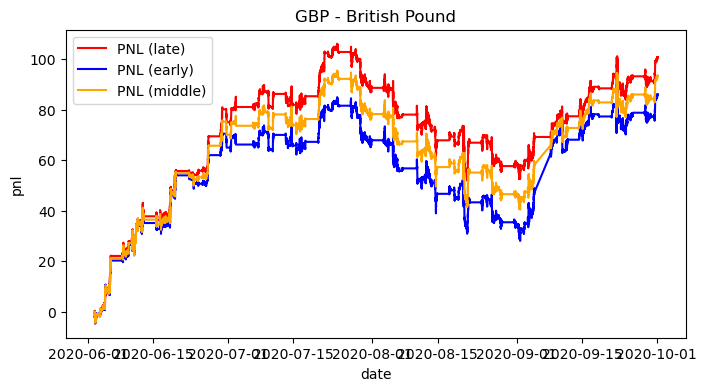

========== German Bunds - German Government Bonds ==========
            count  mean   std   min  25%  50%  75%   max
position  28580.0  2.68  3.76 -12.0  0.0  2.0  5.0  23.0
trade     28580.0  0.00  0.55 -12.0  0.0  0.0  0.0  11.0


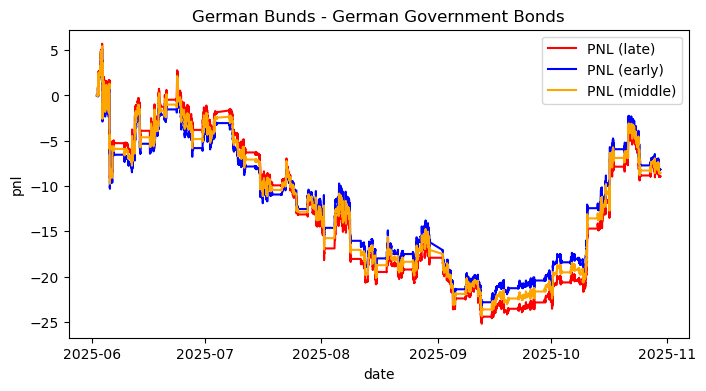

========== Gold ==========
            count  mean   std  min  25%  50%  75%  max
position  28497.0   1.6  2.76 -7.0  0.0  1.0  3.0  8.0
trade     28497.0   0.0  0.45 -7.0  0.0  0.0  0.0  6.0


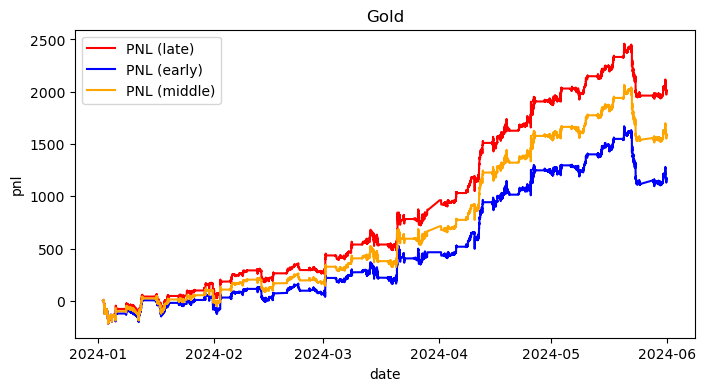

========== HeatingOil ==========
            count  mean   std  min  25%  50%  75%  max
position  22864.0  1.34  1.96 -4.0  0.0  1.0  2.0  6.0
trade     22864.0 -0.00  0.26 -5.0  0.0  0.0  0.0  7.0


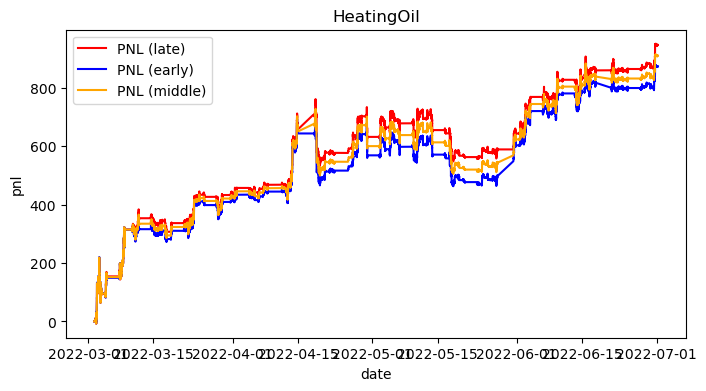

========== JPY - Japanese Yen ==========
            count  mean   std   min  25%  50%  75%  max
position  22205.0 -2.36  3.05 -10.0 -5.0 -2.0  0.0  8.0
trade     22205.0  0.00  0.65 -10.0  0.0  0.0  0.0  9.0


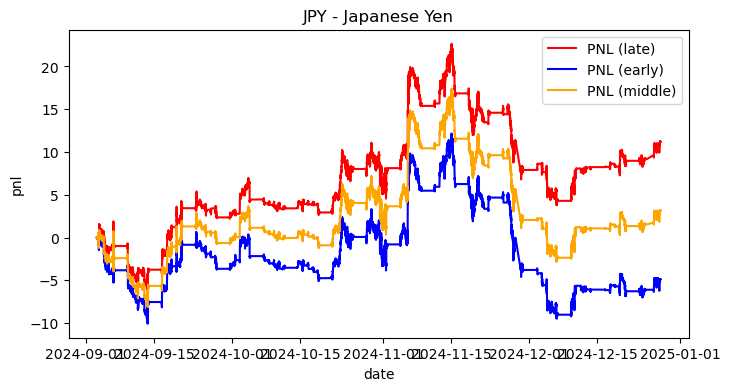

========== Nasdaq ==========
            count  mean   std   min  25%  50%  75%   max
position  27921.0  4.26  3.64 -11.0  2.0  4.0  7.0  11.0
trade     27921.0  0.00  1.18 -16.0  0.0  0.0  0.0  17.0


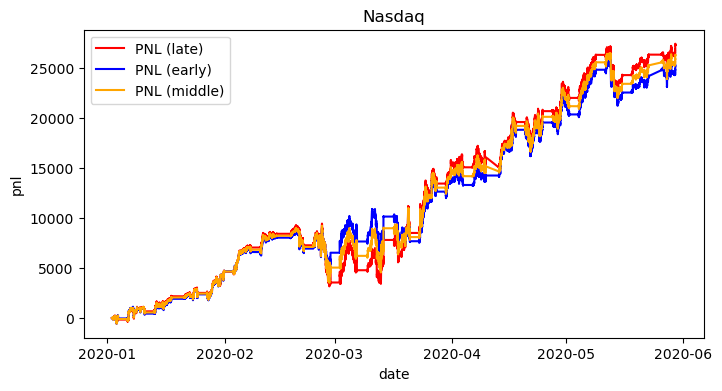

In [43]:
def show_agent_pnl(
    data_path:Path,
)->None:
    
    files=sorted([p.name for p in data_path.glob("*.parquet")])
    markets=[f[:-8] for f in files]
    print(f'All Markets: {markets}')
    print(f'Number of markets: {len(markets)}')

    for market in markets:
        print(f'========== {market} ==========')
        data=pd.read_parquet(data_path/f'{market}.parquet')
        data['trade']=data['position'].diff()
        data['trade']=data['trade'].fillna(0)
        data['position']=data['position'].ffill()
        print(data[['position','trade']].dropna().describe().round(2).T)
        
        data['cash_1']=-data['trade']*data['price'] # latter price
        data['cash_2']=(-data['trade']*data['price'].shift()).fillna(0) # former price
        data['cash_3']=(-data['trade']*(data['price'].shift()+data['price'])/2).fillna(0) # middle price
        data['inventory']=data['position']*data['price']
        data['PNL_1']=data['cash_1'].cumsum()+data['inventory']
        data['PNL_2']=data['cash_2'].cumsum()+data['inventory']
        data['PNL_3']=data['cash_3'].cumsum()+data['inventory']

        plt.figure(figsize=(8,4))
        plt.plot(data['time'],data['PNL_1'],color='red',label='PNL (late)')
        plt.plot(data['time'],data['PNL_2'],color='blue',label='PNL (early)')
        plt.plot(data['time'],data['PNL_3'],color='orange',label='PNL (middle)')
        plt.xlabel('date')
        plt.ylabel('pnl')
        plt.title(market)
        plt.legend()
        plt.show()

       
data_path=DATA_DIR/'agent'
show_agent_pnl(data_path)